# 类激活图  
卷积神经网络的决策过程难以解释和理解。类激活图 (Class Activation Map, CAM) 是一种可视化技术，用于解释深度学习模型在图像分类任务中的决策过程。它能够显示出对于分类结果影响最显著的图像区域，从而提供对模型决策的可解释性。通过观察类激活图，可以理解模型在分类决策中注重的区域和特征，这有助于我们分析和解释模型的决策依据，以及验证模型是否关注了正确的特征。本节中，将介绍类激活图的基本概念，并使用训练好的模型生成图像的类激活图。

# 1. 类激活图  
## 1.1 基本概念  
类激活图 (Class Activation Map, CAM) 是一种用于可视化卷积神经网络 (Convolutional Neural Networks, CNN) 中每个类别的局部重要性的技术，使用 CAM 可以帮助我们理解 CNN 的决策过程，以及哪些特征对于某个类别的分类最为重要。一个示例 CAM 如下所示，其中左侧是输入图像，右侧突出显示了用于类别预测的像素：

![13.1](../Images/13.1.png)

根据以上激活图可以看到高激活区域集中在最有助于模型作出类别预测的部位。接下来，我们将继续介绍如何在训练好模型后生成 CAM。

## 1.2 类激活图生成  
特征图是卷积操作后的中间激活，通常特征图的形状为 batch size x height x width，其中 batch size 表示批大小，height 表示特征图高度，width 表示特征图宽度。如果我们计算这些激活的平均值，它们就显示了图像中所有类别的热点区域。但是，如果我们只对某个特定类别(比如猫)重要的位置感兴趣，那么我们需要找出 n 个通道中只负责该类别的特征映射。对于生成这些特征映射的卷积层，我们可以计算其相对于猫类的梯度。请注意，只有负责预测猫的通道才会具有较高的梯度。这意味着我们可以使用梯度信息赋予 n 个通道中的每一个权重，并且得到一个专门用于猫的激活映射。  
具体而言，我们可以使用以下过程生成 CAM，过程参考自 [Grad-CAM: Gradient-weighted Class Activation Mapping：](https://arxiv.org/abs/1610.02391)

1. 确定要为哪个类别计算 CAM，以及要为神经网络中的哪个卷积层计算 CAM​
2. 计算卷积层产生的激活——假设卷积层的特征形状为 512 x 7 x 7​
3. 获取从该层产生的关于兴趣类别的梯度值，输出梯度形状为 256 x 512 x 3 x 3 (卷积张量的形状——即，batch size x height x width x kernel size，其中 kernel size 表示核尺寸)​
4. 计算每个输出通道内梯度的平均值，输出形状为 512​
5. 计算加权激活图——512 个梯度均值乘以 512 个激活通道，输出形状为 512 x 7 x 7​
6. 计算加权激活图的平均值(跨 512 个通道)，获取形状为 7 x 7 的输出​
7. 调整(放大)加权激活图输出的大小，以得到与输入大小相同的图像，目的是得到与原始图像尺寸相同的激活图​
8. 将加权激活图叠加到输入图像上

整个过程的关键在于步骤 5，考虑以下两个方面：  
- 如果某个像素很重要，那么卷积神经网络 (Convolutional Neural Networks, CNN) 将在这些像素处得到较大的激活​
- 如果某个卷积通道对于兴趣类别很重要，则该通道的梯度将非常大​
将这两者相乘后，将得到所有像素的重要性映射，重要性映射 (map of importance) 是指将神经网络中某个像素或特征的重要性表示为一个热力图或概率分布图，通常用于可视化神经网络输出中哪些部分对识别特定类别最为重要。

## 2. 数据集分析  
Malaria Cell Images Dataset 是一个常用的数据集，用于训练和评估计算机视觉模型在疟疾细胞图像分类任务上的性能。该数据集包含了被感染和未被感染的红血细胞图像，通常用于研究和开发自动检测和分类疟疾细胞的算法。通过使用这个数据集，可以构建深度学习模型来自动识别感染疟疾的红血细胞，从而帮助医生进行准确的诊断，在 Kaggle 官方网站下载 Malaria Cell Images Dataset

## 3. 使用PyTorch生成CAM  
接下来，我们使用 PyTorch 实现 CAM 生成策略，以了解 CNN 模型能够预测图像可能出现疟疾事件的原因。

1. 下载数据集并导入相关库

In [27]:
import os
import torch
import numpy as np
from torch.utils.data import DataLoader, Dataset
from glob import glob
from random import randint
import cv2
from pathlib import Path
import torch.nn as nn
from torch import optim
from matplotlib import pyplot as plt

device = "cpu"

2. 指定与输出类别对应的索引：

In [28]:
id2int = {'Parasitized': 0, 'Uninfected': 1} 

3. 执行图形转换操作：

In [29]:
from torchvision import transforms as T

trn_tfms = T.Compose([
    T.ToPILImage(),
    T.Resize(128),
    T.CenterCrop(128),
    T.ColorJitter(brightness=(0.95,1.05),
                  contrast=(0.95,1.05),
                  saturation=(0.95,1.05),
                  hue=0.05),
    T.RandomAffine(5, translate=(0.01,0.1)),
    T.ToTensor(),
    T.Normalize(mean=[0.5, 0.5, 0.5],
                std=[0.5, 0.5, 0.5]),
])

在以上代码中，对输入图像进行了一系列转换——首先将图像尺寸调整为 128 (最小边为 128)，然后从图像中心进行裁剪。此外，我们还进行了随机颜色抖动和仿射变换，并使用 .ToTensor() 方法对图像进行缩放(使像素值位于0到1之间)，最后对图像进行归一化处理。

对验证集图像执行转换：

In [30]:
val_tfms = T.Compose([
    T.ToPILImage(),
    T.Resize(128),
    T.CenterCrop(128),
    T.ToTensor(),
    T.Normalize(mean=[0.5, 0.5, 0.5],
                std=[0.5, 0.5, 0.5]),
])

4. 定义数据集类MalariaImages：

In [31]:
class MalariaImages(Dataset):
    def __init__(self, files, transform=None):
        self.files = files
        self.transform = transform

    def __len__(self):
        return len(self.files)

    def __getitem__(self, ix):
        fpath = self.files[ix]
        clss = os.path.basename(Path(fpath).parent)
        img = cv2.imread(fpath)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        return img, clss

    def choose(self):
        return self[randint(len(self))]

    def collate_fn(self, batch):
        _imgs, classes = list(zip(*batch))
        if self.transform:
            imgs = [self.transform(img)[None] for img in _imgs]
        classes = [torch.tensor([id2int[clss]]) for clss in classes]
        imgs, classes = [torch.cat(i).to(device) for i in [imgs, classes]]
        return imgs, classes, _imgs

5. 获取训练、验证数据集和数据加载器：

In [32]:
all_files = glob(
    r"E:\pwr\leaning\Start-with-Pytorch\data\archive\cell_images\cell_images\*\*.png"
)
np.random.shuffle(all_files)

from sklearn.model_selection import train_test_split
trn_files, val_files = train_test_split(all_files, random_state=1)

trn_ds = MalariaImages(trn_files, transform=trn_tfms)
val_ds = MalariaImages(val_files, transform=val_tfms)
trn_dl = DataLoader(trn_ds, 32, shuffle=True, collate_fn=trn_ds.collate_fn)
val_dl = DataLoader(val_ds, 32, shuffle=False, collate_fn=val_ds.collate_fn)

6. 定义模型 MalariaClassifier：

In [33]:
def convBlock(ni, no):
    return nn.Sequential(
        nn.Dropout(0.2),
        nn.Conv2d(ni, no, kernel_size=3, padding=1),
        nn.ReLU(inplace=True),
        nn.BatchNorm2d(no),
        nn.MaxPool2d(2),
    )

class MalariaClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            convBlock(3, 64),
            convBlock(64, 64),
            convBlock(64, 128),
            convBlock(128, 256),
            convBlock(256, 512),
            convBlock(512, 64),
            nn.Flatten(),
            nn.Linear(256, 256),
            nn.Dropout(0.2),
            nn.ReLU(inplace=True),
            nn.Linear(256, len(id2int))
        )
        self.loss_fn = nn.CrossEntropyLoss()

    def forward(self, x):
        return self.model(x)

    def compute_metrics(self, preds, targets):
        loss = self.loss_fn(preds, targets)
        acc = (torch.max(preds, 1)[1] == targets).float().mean()
        return loss, acc

7. 定义使用批数据对模型进行训练和验证的函数：

In [34]:
def train_batch(model, data, optimizer, criterion):
    model.train()
    ims, labels, _ = data
    _preds = model(ims)
    optimizer.zero_grad()
    loss, acc = criterion(_preds, labels)
    loss.backward()
    optimizer.step()
    return loss.item(), acc.item()

@torch.no_grad()
def validate_batch(model, data, criterion):
    model.eval()
    ims, labels, _ = data
    _preds = model(ims)
    loss, acc = criterion(_preds, labels)
    return loss.item(), acc.item()

8. 训练模型

In [35]:
model = MalariaClassifier().to(device)
criterion = model.compute_metrics
optimizer = optim.Adam(model.parameters(), lr=1e-3)
n_epochs = 5

for ex in range(n_epochs):
    train_loss = []
    train_acc = []
    val_loss = []
    val_acc = []
    N = len(trn_dl)
    for bx, data in enumerate(trn_dl):
        loss, acc = train_batch(model, data, optimizer, criterion)
        train_loss.append(loss)
        train_acc.append(acc)
    N = len(val_dl)
    for bx, data in enumerate(val_dl):
        loss, acc = validate_batch(model, data, criterion)
        val_loss.append(loss)
        val_acc.append(acc)
    avg_train_loss = np.average(train_loss)
    avg_train_acc = np.average(train_acc)
    avg_val_loss = np.average(val_loss)
    avg_val_acc = np.average(val_acc)
    print(f"EPOCH: {ex}        trn_loss: {avg_train_loss}        trn_acc: {avg_train_acc}        val_loss: {avg_val_loss}        val_acc: {avg_val_acc}")

EPOCH: 0        trn_loss: 0.2544826915741382        trn_acc: 0.8986482751258755        val_loss: 0.15403549945740788        val_acc: 0.9529803240740741
EPOCH: 1        trn_loss: 0.17062083895003924        trn_acc: 0.9453228659489575        val_loss: 0.1730561817616776        val_acc: 0.9510995370370371
EPOCH: 2        trn_loss: 0.1615334968428609        trn_acc: 0.946546052631579        val_loss: 0.1393153147806448        val_acc: 0.9541377314814815
EPOCH: 3        trn_loss: 0.1544527338223745        trn_acc: 0.9484810371517027        val_loss: 0.15184415969997644        val_acc: 0.9545717592592593
EPOCH: 4        trn_loss: 0.149281395750622        trn_acc: 0.9508997678018576        val_loss: 0.154470746991811        val_acc: 0.9526909722222222


9. 获取模型中第五个 convBlock 中的卷积层:

In [36]:
im2fmap = nn.Sequential(*(list(model.model[:5].children()) + list(model.model[5][:2].children())))

在以上代码中，获取模型的第四层以及 convBlock 中的前两层(均为 Conv2D 层)。

10. 定义 im2gradCAM 函数，该函数接受输入图像并获取与图像激活对应的热力图：

In [37]:
def im2gradCAM(x):
    model.eval()
    logits = model(x)
    heatmaps = []
    activations = im2fmap(x)
    print(activations.shape)
    pred = logits.max(-1)[-1]
    # 获取模型预测
    model.zero_grad()
    # 计算相对于模型置信度最高的 logits 的梯度
    logits[0,pred].backward(retain_graph=True)
    # 获取所需特征图位置的梯度，并对每个特征图取平均梯度
    pooled_grads = model.model[-6][1].weight.grad.data.mean((1,2,3))
    # 将每个激活图与对应的梯度平均值相乘
    for i in range(activations.shape[1]):
        activations[:,i,:,:] *= pooled_grads[i]
    # 计算所有加权激活图的平均值
    heatmap = torch.mean(activations, dim=1)[0].cpu().detach()
    return heatmap, 'Uninfected' if pred.item() else 'Parasitized'

11. 定义 upsampleHeatmap 函数将热图上采样为与图像形状对应的形状：

In [38]:
SZ = 120
def upsampleHeatmap(map, img):
    m,M = map.min(), map.max()
    map = 255 * ((map-m) / (M-m))
    map = np.uint8(map)
    map = cv2.resize(map, (SZ,SZ))
    map = cv2.applyColorMap(255-map, cv2.COLORMAP_JET)
    map = np.uint8(map)
    map = np.uint8(map*0.7 + img*0.3)
    return map

在前面的代码行中，我们对图像进行了反归一化，并将热图覆盖在图像之上。

12. 使用一组测试图像调用上述函数：

torch.Size([1, 64, 4, 4])


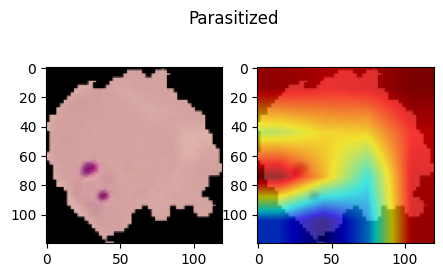

torch.Size([1, 64, 4, 4])


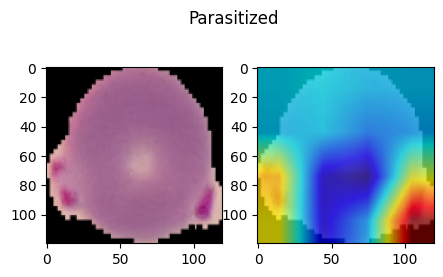

torch.Size([1, 64, 4, 4])


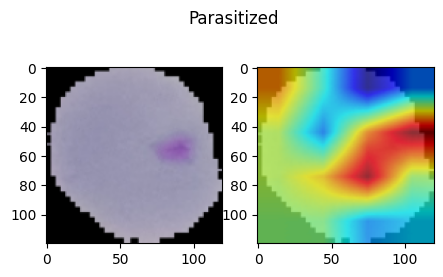

torch.Size([1, 64, 4, 4])


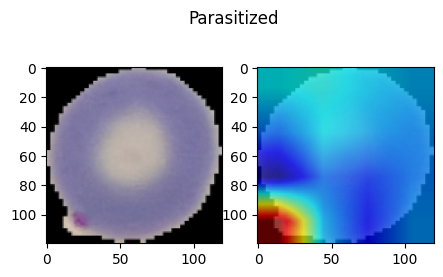

torch.Size([1, 64, 4, 4])


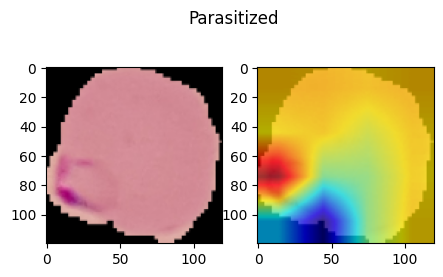

torch.Size([1, 64, 4, 4])
torch.Size([1, 64, 4, 4])


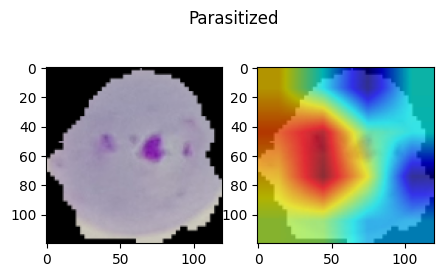

torch.Size([1, 64, 4, 4])
torch.Size([1, 64, 4, 4])


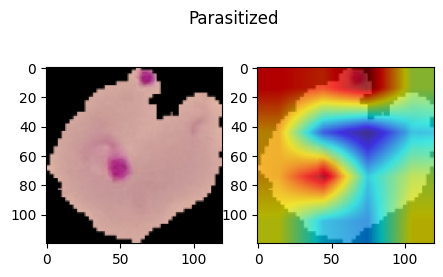

torch.Size([1, 64, 4, 4])
torch.Size([1, 64, 4, 4])


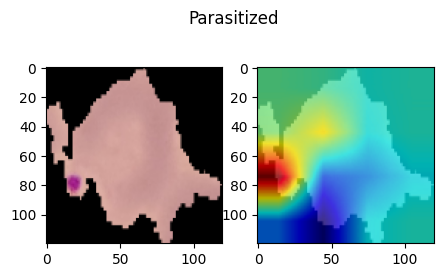

torch.Size([1, 64, 4, 4])


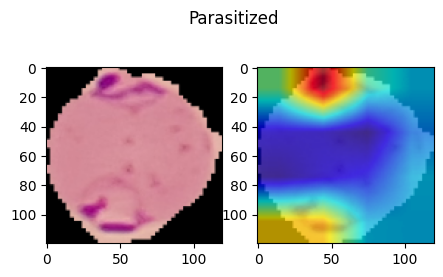

torch.Size([1, 64, 4, 4])


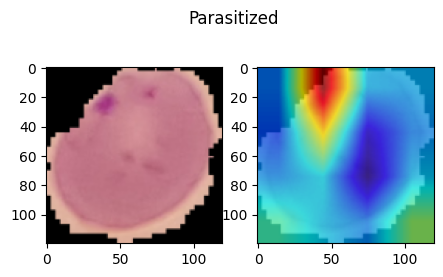

torch.Size([1, 64, 4, 4])
torch.Size([1, 64, 4, 4])


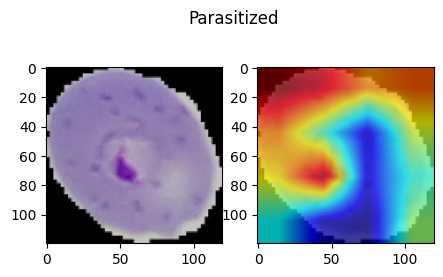

torch.Size([1, 64, 4, 4])
torch.Size([1, 64, 4, 4])


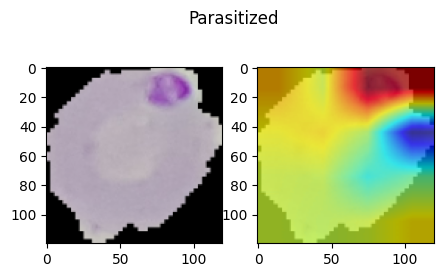

torch.Size([1, 64, 4, 4])
torch.Size([1, 64, 4, 4])
torch.Size([1, 64, 4, 4])


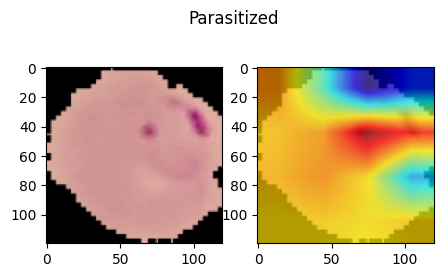

In [39]:
N = 20
_val_dl = DataLoader(val_ds, batch_size=N, shuffle=True, collate_fn=val_ds.collate_fn)
x,y,z = next(iter(_val_dl))

for i in range(N):
    image = cv2.resize(z[i], (SZ, SZ))
    heatmap, pred = im2gradCAM(x[i:i+1])
    if(pred=='Uninfected'):
        continue
    heatmap = upsampleHeatmap(heatmap, image)
    plt.figure(figsize=(5,3))
    plt.subplot(121)
    plt.imshow(image)
    plt.subplot(122)
    plt.imshow(heatmap)
    plt.suptitle(pred)
    plt.show()

从图中可以看出，预测结果是由红色高亮区域的内容决定的(这部分区域具有最高的 CAM 值)。学习了如何使用训练好的模型生成图像的类激活热力图，我们就可以解释是什么原因导致了模型产生某个分类结果。

## 小结  
类激活图的生成方法主要基于卷积神经网络模型的最后一个卷积层和全局平均池化层。首先，通过前向传播将图像输入到卷积神经网络中，然后获取最后一个卷积层的特征图。接着，利用全局平均池化对每个特征通道的权重进行计算，得到每个通道对分类结果的重要性。之后，将原始图像与特征图的权重相乘，并进行叠加，最终得到一个类激活图。类激活图中像素值较高的区域表示对于分类结果贡献较大的图像区域，而像素值较低的区域则表示贡献较小或无关的区域。